## Imports

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [21]:
sns.set_style("whitegrid")

embeddings_df = pd.read_csv('simple_results.csv').drop_duplicates(subset=['model', 'classifier'], keep='first')
unigrams_df = pd.read_csv('unigrams_results.csv')
tfidf_df = pd.read_csv('tfidf_results.csv')

embeddings_df['method_type'] = 'Embeddings'
unigrams_df['method_type'] = 'Baseline'
tfidf_df['method_type'] = 'Baseline'

embeddings_df = embeddings_df.rename(columns={'model': 'method'})
all_data = pd.concat([embeddings_df, unigrams_df, tfidf_df], ignore_index=True)

### PLOT 1: Ranked Bar Chart - All Methods

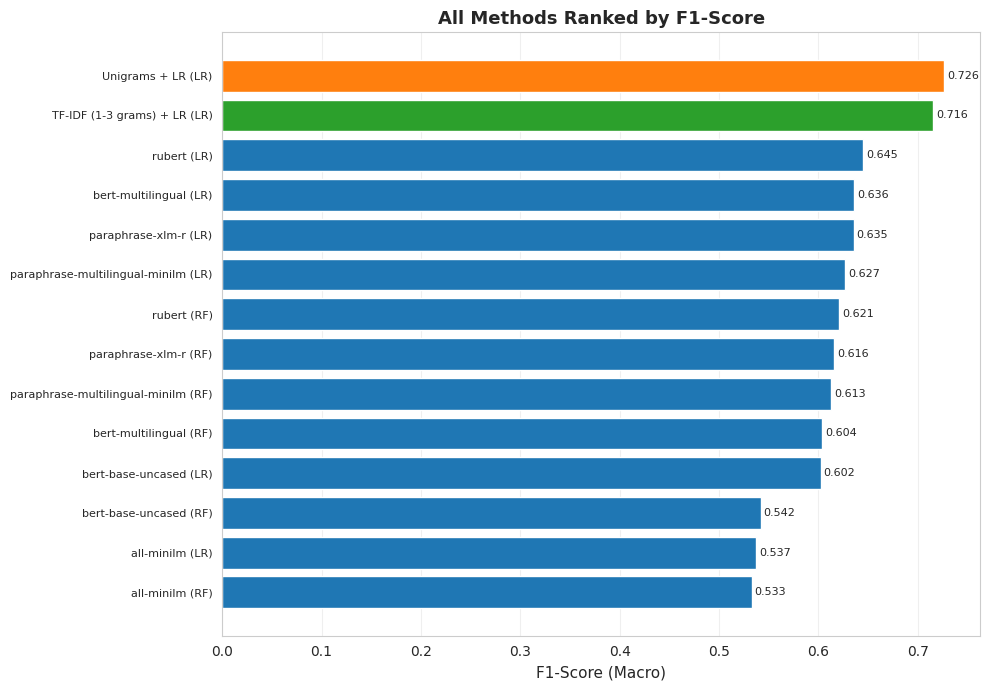

In [32]:
fig, ax = plt.subplots(figsize=(10, 7))

sorted_data = all_data.sort_values('f1_macro', ascending=True)
colors = ['#2ca02c' if 'TF-IDF' in m else '#ff7f0e' if 'Unigrams' in m else '#1f77b4' 
          for m in sorted_data['method']]

ax.barh(range(len(sorted_data)), sorted_data['f1_macro'], color=colors)
ax.set_yticks(range(len(sorted_data)))
ax.set_yticklabels([f"{m} ({c})" for m, c in zip(sorted_data['method'], sorted_data['classifier'])], fontsize=8)
ax.set_xlabel('F1-Score (Macro)', fontsize=11)
ax.set_title('All Methods Ranked by F1-Score', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.grid(axis='y', alpha=0)

for i, v in enumerate(sorted_data['f1_macro']):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('plots/plot1_ranked.png', dpi=150, bbox_inches='tight')
plt.show()

### PLOT 2: Grouped Bar - Top 5 with All Metricsx

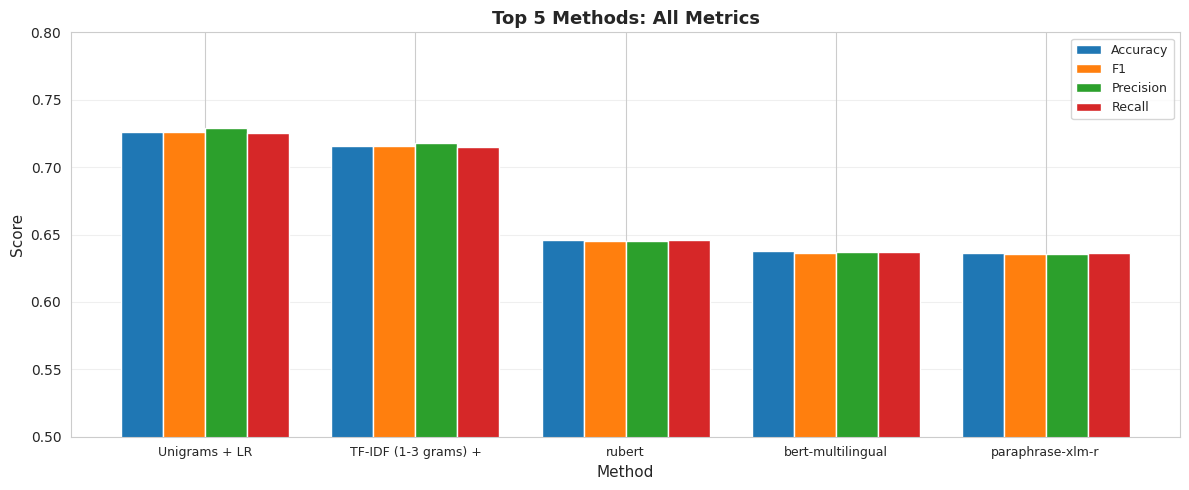

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

top5 = all_data.nlargest(5, 'f1_macro')
metrics = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']
x = np.arange(len(top5))
width = 0.2

for i, metric in enumerate(metrics):
    ax.bar(x + i*width - 1.5*width, top5[metric], width, 
           label=metric.replace('_macro', '').replace('_', ' ').title())

ax.set_xlabel('Method', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Top 5 Methods: All Metrics', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{m[:20]}" for m in top5['method']], fontsize=9)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.5, 0.8)

plt.tight_layout()
plt.savefig('plots/plot2_top5_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


### PLOT 3: Heatmap - F1 Scores


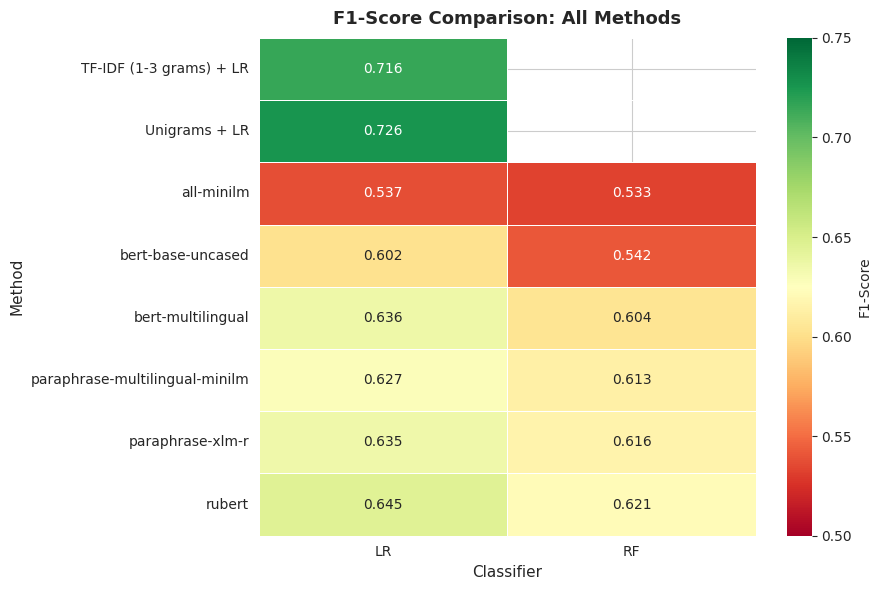

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))

pivot_f1 = all_data.pivot_table(index='method', columns='classifier', values='f1_macro')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.75,
            linewidths=0.5, cbar_kws={'label': 'F1-Score'}, ax=ax)

ax.set_title('F1-Score Comparison: All Methods', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Classifier', fontsize=11)
ax.set_ylabel('Method', fontsize=11)

plt.tight_layout()
plt.savefig('plots/plot3_heatmap_f1.png', dpi=150, bbox_inches='tight')
plt.show()

### PLOT 4: Scatter - Precision vs Recall

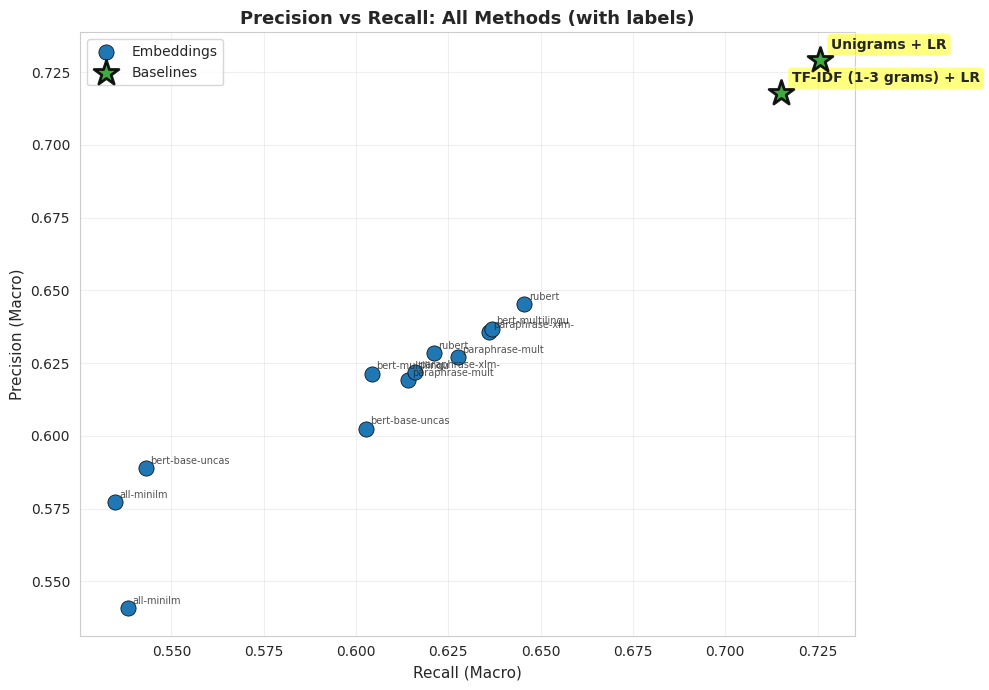

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

embeddings_subset = all_data[all_data['method_type'] == 'Embeddings']
ax.scatter(embeddings_subset['recall_macro'], embeddings_subset['precision_macro'], 
          s=120, alpha=0.7, label='Embeddings', marker='o', c='#1f77b4', edgecolors='black', linewidth=0.5)

for _, row in embeddings_subset.iterrows():
    ax.annotate(f"{row['method'][:15]}", 
               (row['recall_macro'], row['precision_macro']),
               xytext=(3, 3), textcoords='offset points', fontsize=7, alpha=0.8)

baselines_subset = all_data[all_data['method_type'] == 'Baseline']
ax.scatter(baselines_subset['recall_macro'], baselines_subset['precision_macro'], 
          s=350, alpha=0.9, label='Baselines', marker='*', c='#2ca02c', edgecolors='black', linewidth=2, zorder=10)

for _, row in baselines_subset.iterrows():
    ax.annotate(row['method'], 
               (row['recall_macro'], row['precision_macro']),
               xytext=(8, 8), textcoords='offset points', fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

ax.set_xlabel('Recall (Macro)', fontsize=11)
ax.set_ylabel('Precision (Macro)', fontsize=11)
ax.set_title('Precision vs Recall: All Methods (with labels)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/plot4_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

### PLOT 5: Box Plot - Performance by Method Type

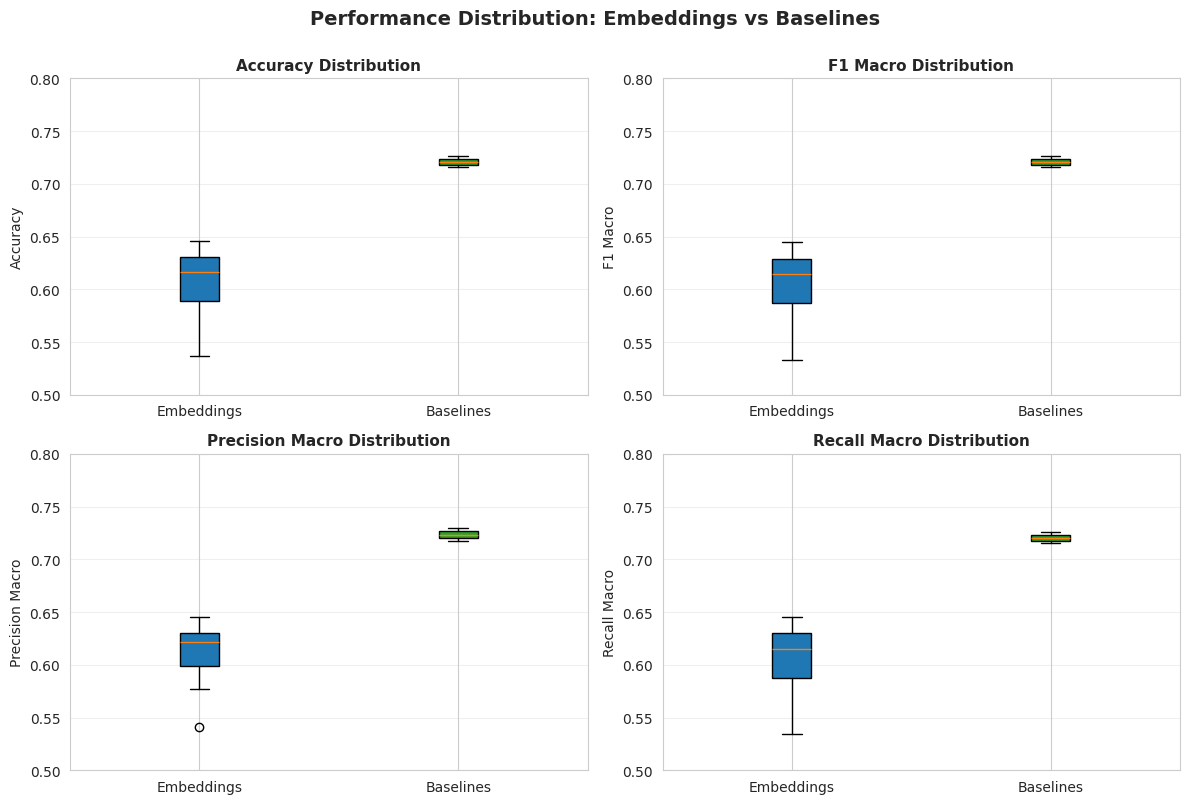

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, metric in zip(axes.flat, ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']):
    data_to_plot = [
        all_data[all_data['method_type'] == 'Embeddings'][metric],
        all_data[all_data['method_type'] == 'Baseline'][metric]
    ]
    
    bp = ax.boxplot(data_to_plot, tick_labels=['Embeddings', 'Baselines'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#1f77b4')
    bp['boxes'][1].set_facecolor('#2ca02c')
    
    ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=10)
    ax.set_title(f'{metric.replace("_", " ").title()} Distribution', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0.5, 0.8)

plt.suptitle('Performance Distribution: Embeddings vs Baselines', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('plots/plot5_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### PLOT 6: Summary Table


[6] Summary table...


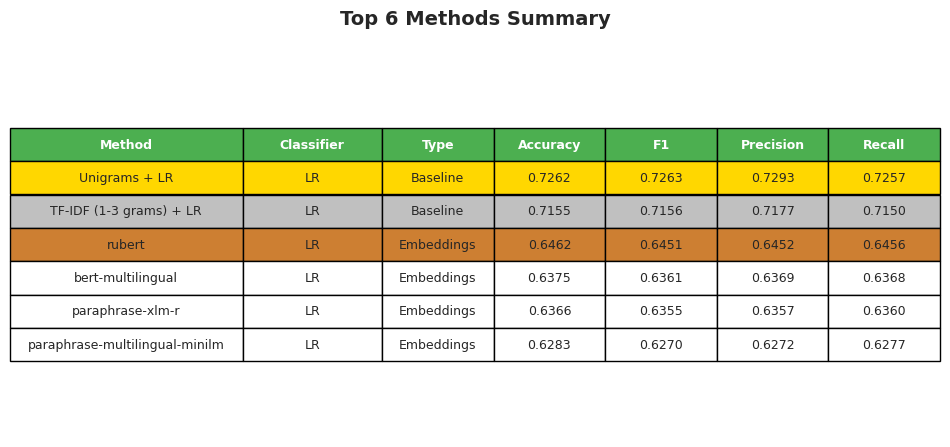

In [27]:
print("\n[6] Summary table...")
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('tight')
ax.axis('off')

summary_data = []
for _, row in all_data.nlargest(6, 'f1_macro').iterrows():
    summary_data.append([
        row['method'],
        row['classifier'],
        row['method_type'],
        f"{row['accuracy']:.4f}",
        f"{row['f1_macro']:.4f}",
        f"{row['precision_macro']:.4f}",
        f"{row['recall_macro']:.4f}"
    ])

table = ax.table(cellText=summary_data,
                colLabels=['Method', 'Classifier', 'Type', 'Accuracy', 'F1', 'Precision', 'Recall'],
                cellLoc='center',
                loc='center',
                colWidths=[0.25, 0.15, 0.12, 0.12, 0.12, 0.12, 0.12])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

for i in range(7):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

for row_idx in [1, 2, 3]:
    for col_idx in range(7):
        table[(row_idx, col_idx)].set_facecolor(['#FFD700', '#C0C0C0', '#CD7F32'][row_idx-1])

plt.title('Top 6 Methods Summary', fontsize=14, fontweight='bold', pad=20)
plt.savefig('plots/plot6_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()
